In [1]:
# Training data
from bcdu import dataset as file

TRAINING_IMAGE_PATH = 'training/images'
TRAINING_MASK_PATH = 'training/masks'

trainingImagePaths = file.getSortedFilePaths(TRAINING_IMAGE_PATH)
trainingMaskPaths = file.getSortedFilePaths(TRAINING_MASK_PATH)

trainDataset = file.datasetGenerator(trainingImagePaths, trainingMaskPaths)
trainDataset

<BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 1), dtype=tf.int32, name=None), TensorSpec(shape=(None, 64, 64, 1), dtype=tf.int32, name=None))>

In [2]:
# Testing data

TESTING_IMAGE_PATH = 'testing/images'
TESTING_MASK_PATH = 'testing/masks'

testingImagePaths = file.getSortedFilePaths(TESTING_IMAGE_PATH)
testingMaskPaths = file.getSortedFilePaths(TESTING_MASK_PATH)

testDataset = file.datasetGenerator(testingImagePaths, testingMaskPaths)
testDataset

<BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 1), dtype=tf.int32, name=None), TensorSpec(shape=(None, 64, 64, 1), dtype=tf.int32, name=None))>

In [3]:
from bcdu import models as M

model = M.BCDU_net_D3(input_size = (64,64,1))
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 64, 64, 1)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 64, 64, 64)   640         ['input_1[0][0]']                
                                                                                                  
 conv2d_1 (Conv2D)              (None, 64, 64, 64)   36928       ['conv2d[0][0]']                 
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 32, 32, 64)   0           ['conv2d_1[0][0]']               
                                                                                              

c:\Users\ITWORK\.conda\envs\tf\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [4]:
# Training
from keras.callbacks import ModelCheckpoint, TensorBoard,ReduceLROnPlateau

BATCH_SIZE = 2
EPOCHS = 10

mcp_save = ModelCheckpoint('bcdu-checkpoints/weight_lstm.hdf5', save_best_only=True, monitor='val_loss', mode='min')
reduce_lr_loss = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=7, verbose=1, min_delta=1e-4, mode='min')

history = model.fit(trainDataset,
              batch_size=BATCH_SIZE,
              epochs=EPOCHS,
              shuffle=True,
              verbose=1,
              validation_data=testDataset, 
              callbacks=[mcp_save, reduce_lr_loss] )

Epoch 1/10
2147/2147 [==============================] - 330s 146ms/step - loss: 0.0569 - accuracy: 0.9904 - val_loss: 0.0663 - val_accuracy: 0.9892 - lr: 1.0000e-04
Epoch 2/10
2147/2147 [==============================] - 311s 144ms/step - loss: 0.0513 - accuracy: 0.9908 - val_loss: 0.0664 - val_accuracy: 0.9892 - lr: 1.0000e-04
Epoch 3/10
2147/2147 [==============================] - 313s 145ms/step - loss: 0.0508 - accuracy: 0.9908 - val_loss: 0.0644 - val_accuracy: 0.9892 - lr: 1.0000e-04
Epoch 4/10
2147/2147 [==============================] - 312s 144ms/step - loss: 0.0510 - accuracy: 0.9908 - val_loss: 0.0723 - val_accuracy: 0.9892 - lr: 1.0000e-04
Epoch 5/10
2147/2147 [==============================] - 311s 144ms/step - loss: 0.0513 - accuracy: 0.9908 - val_loss: 0.0648 - val_accuracy: 0.9892 - lr: 1.0000e-04
Epoch 6/10
2147/2147 [==============================] - 313s 145ms/step - loss: 0.0510 - accuracy: 0.9908 - val_loss: 0.0677 - val_accuracy: 0.9892 - lr: 1.0000e-04
Epoch 7/10

In [5]:
predictions = model.predict(testDataset, batch_size=16, verbose=1)

1094/1094 [==============================] - 28s 20ms/step


1/1 [==============================] - 1s 776ms/step


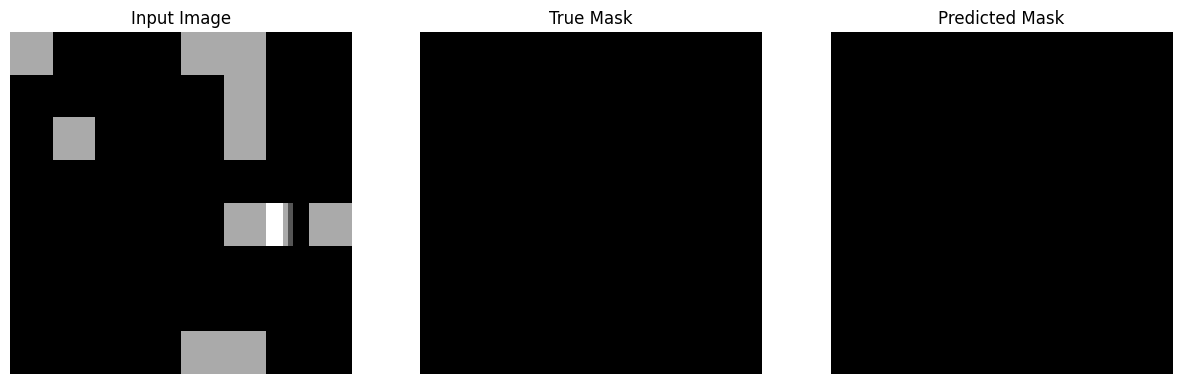

1/1 [==============================] - 0s 29ms/step


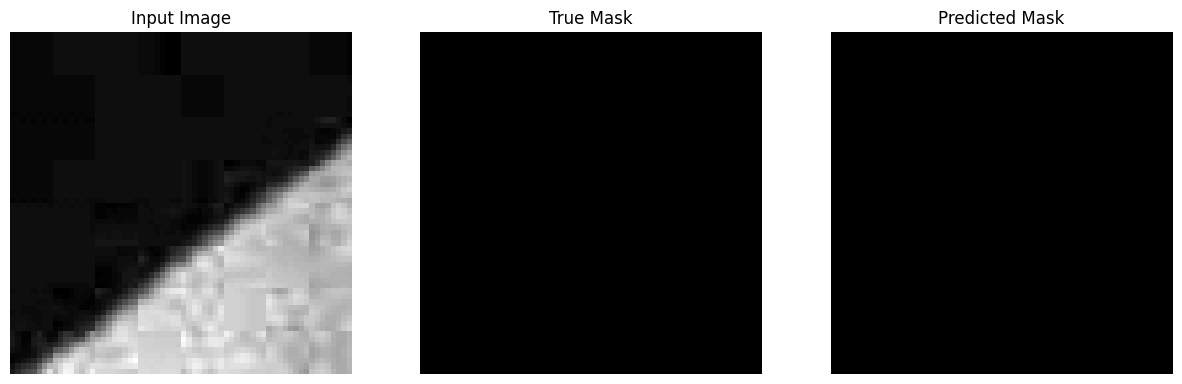

1/1 [==============================] - 0s 26ms/step


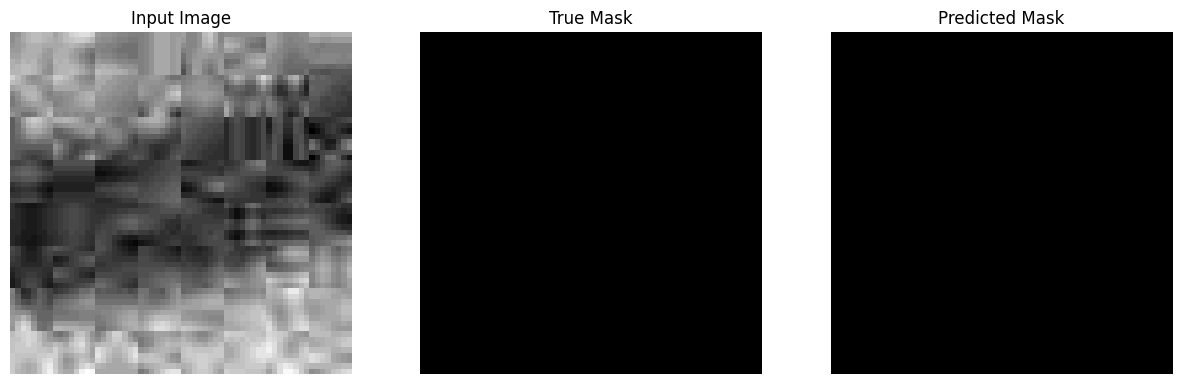

1/1 [==============================] - 0s 29ms/step


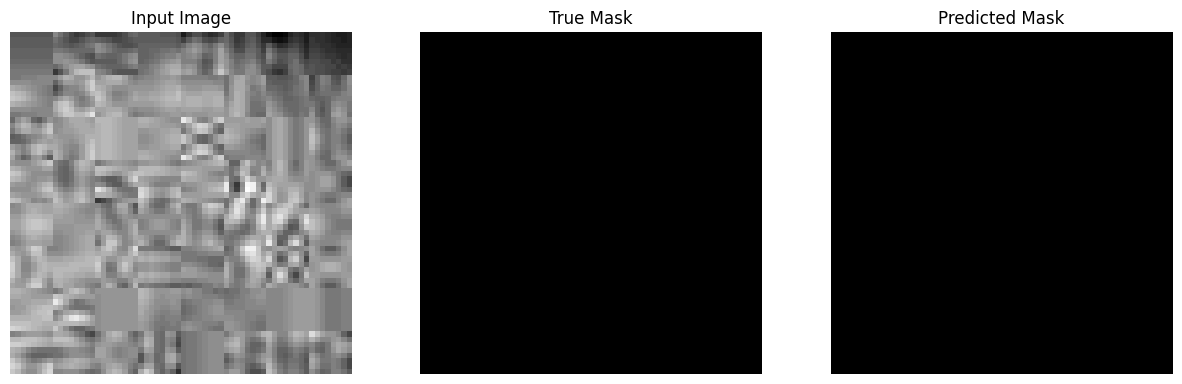

1/1 [==============================] - 0s 27ms/step


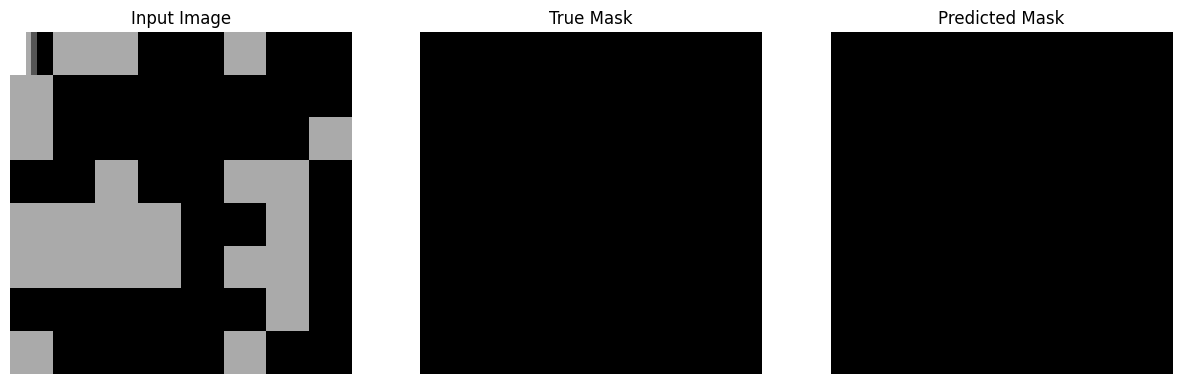

1/1 [==============================] - 0s 28ms/step


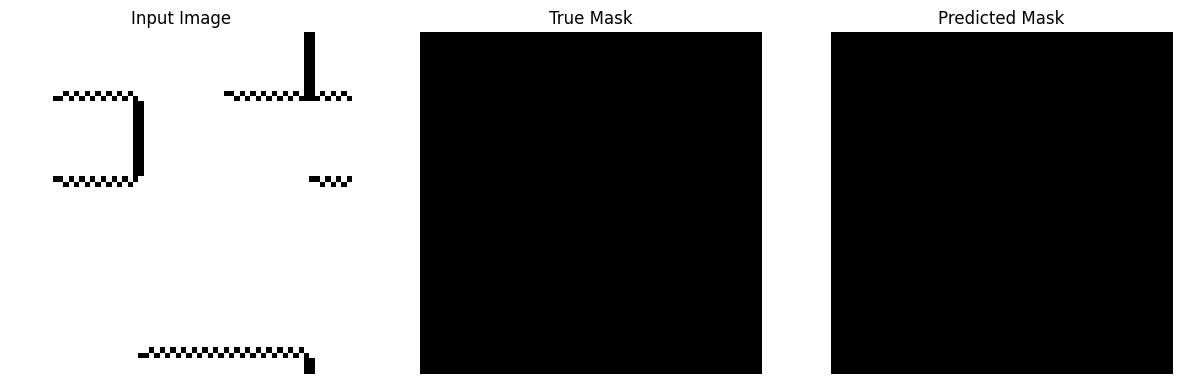

1/1 [==============================] - 0s 28ms/step


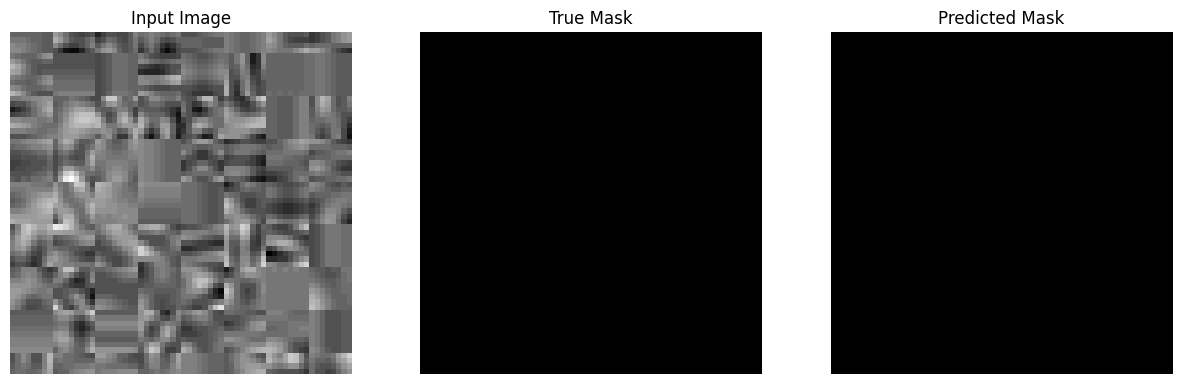

1/1 [==============================] - 0s 26ms/step


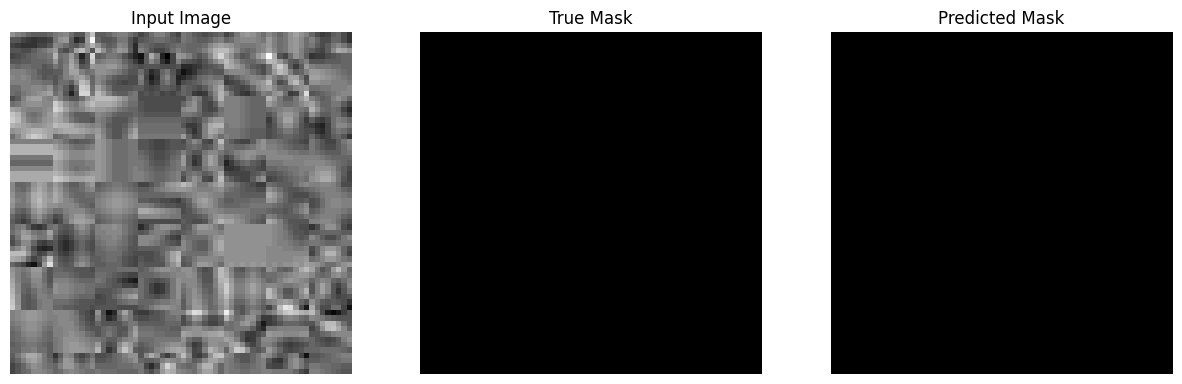

1/1 [==============================] - 0s 27ms/step


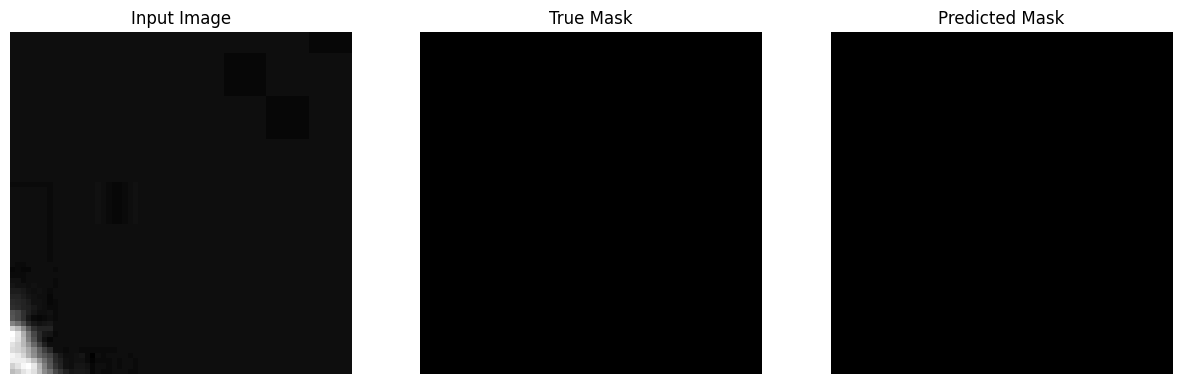

1/1 [==============================] - 0s 26ms/step


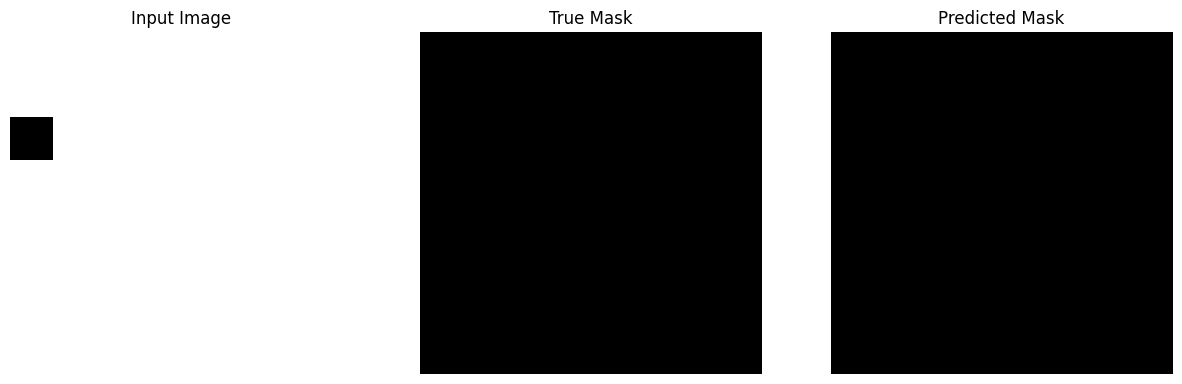

1/1 [==============================] - 0s 27ms/step


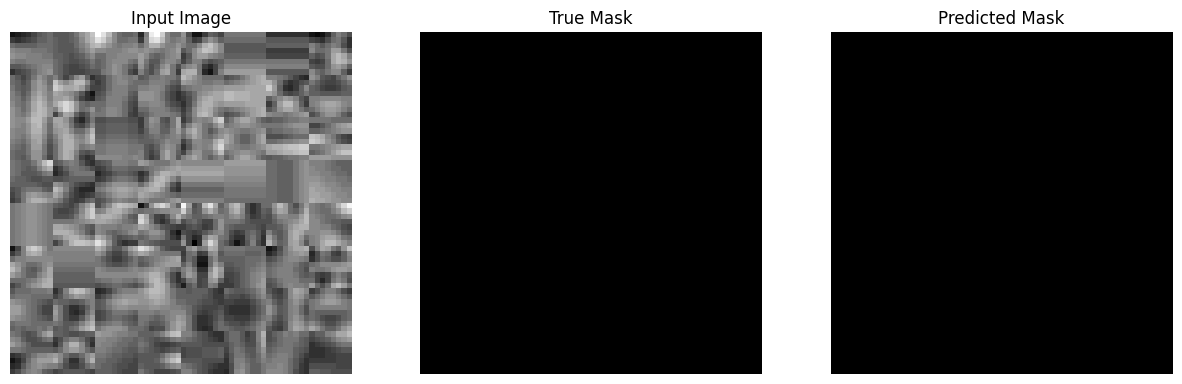

1/1 [==============================] - 0s 26ms/step


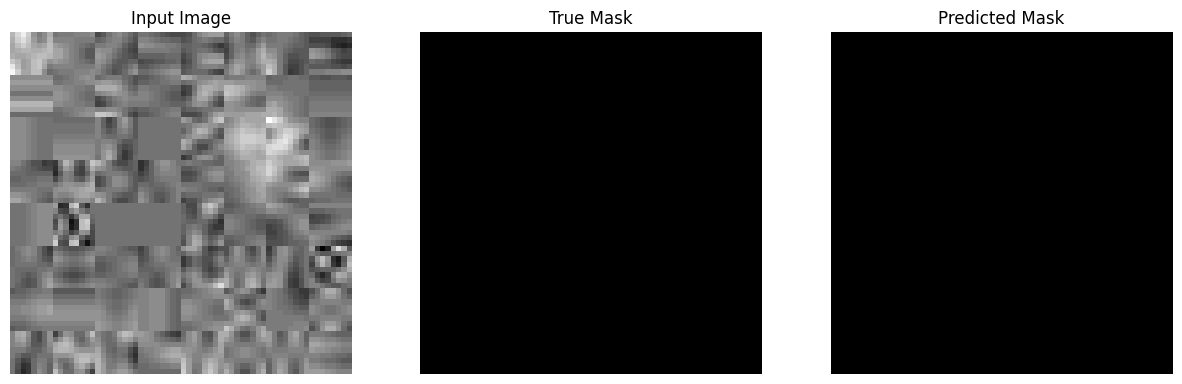

1/1 [==============================] - 0s 26ms/step


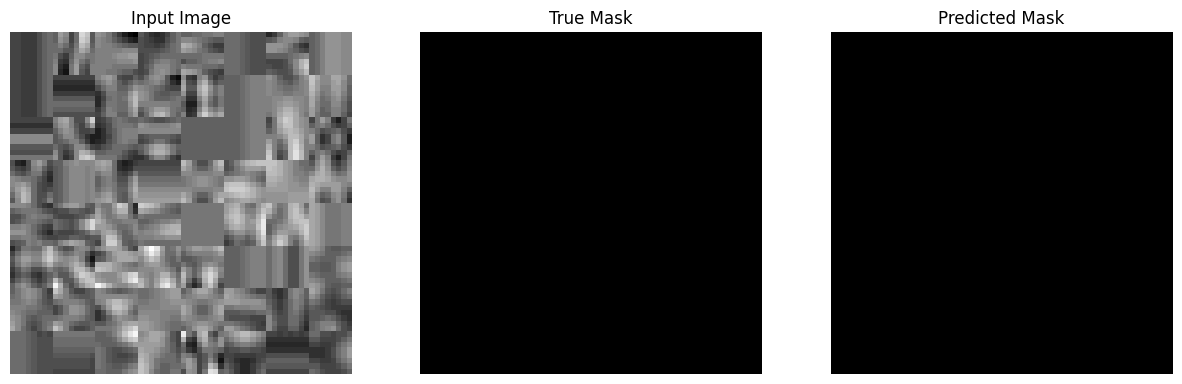

1/1 [==============================] - 0s 28ms/step


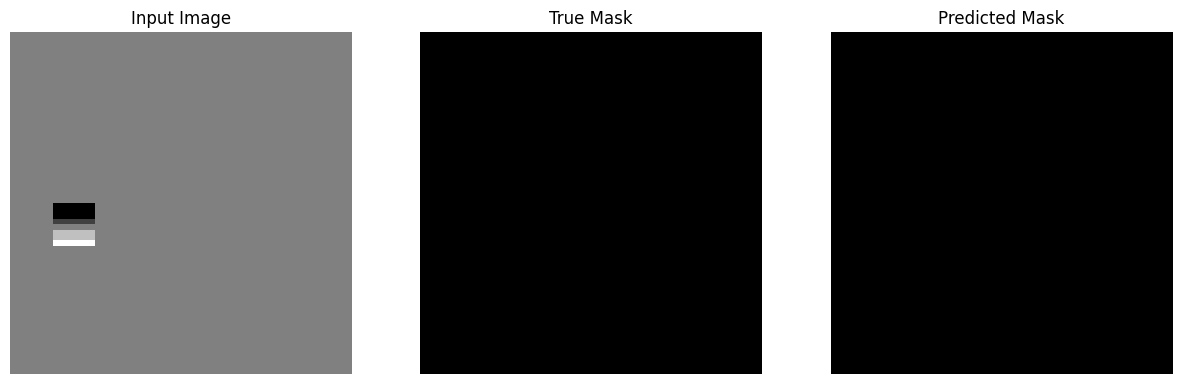

1/1 [==============================] - 0s 26ms/step


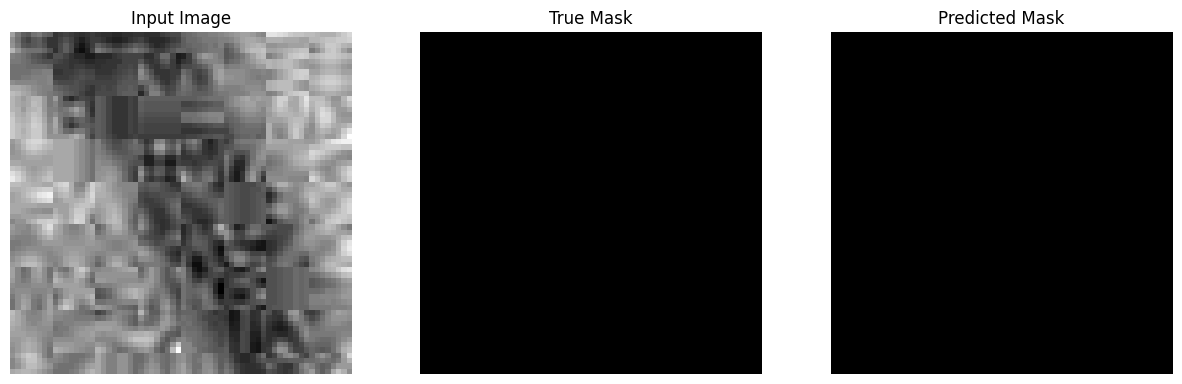

1/1 [==============================] - 0s 42ms/step


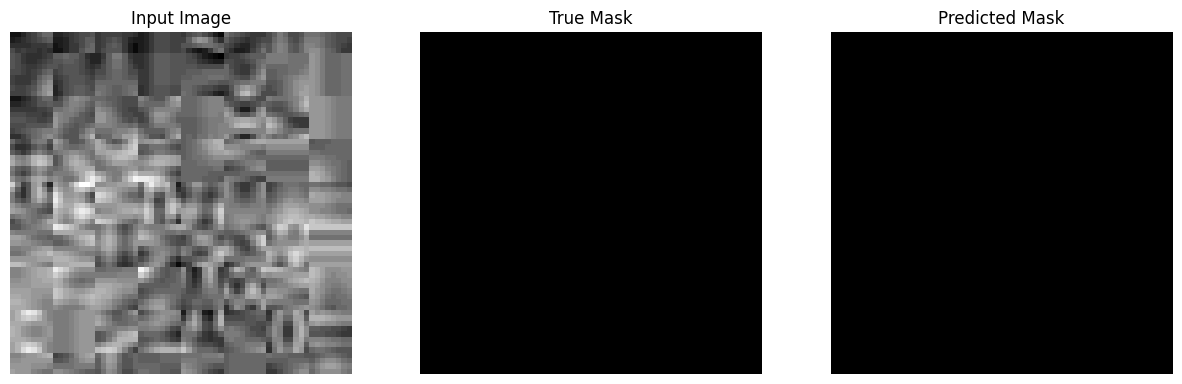

1/1 [==============================] - 0s 28ms/step


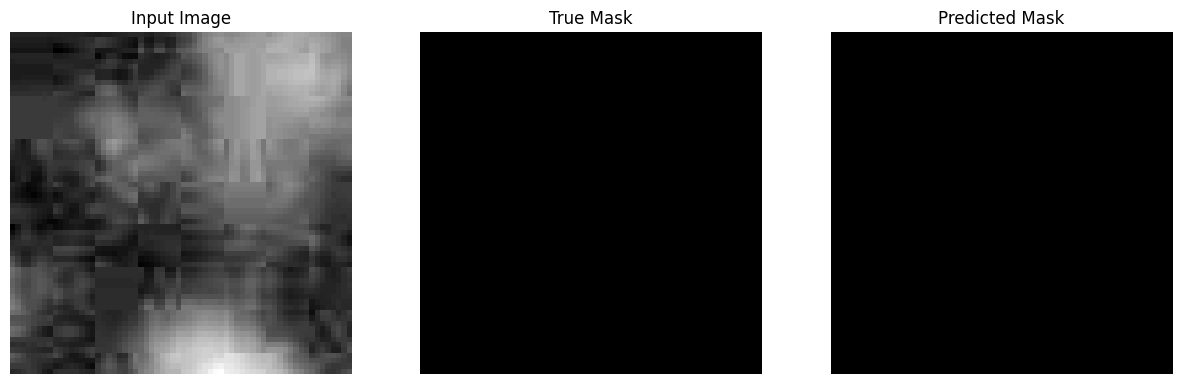

1/1 [==============================] - 0s 28ms/step


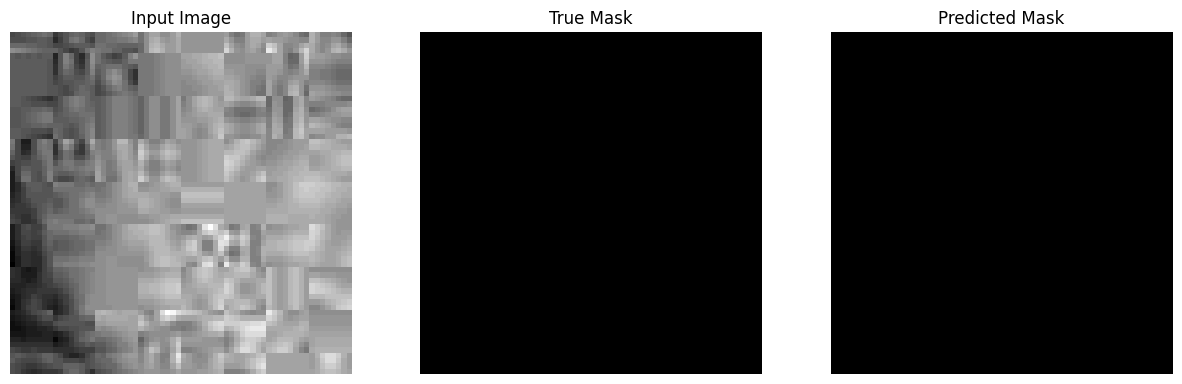

1/1 [==============================] - 0s 25ms/step


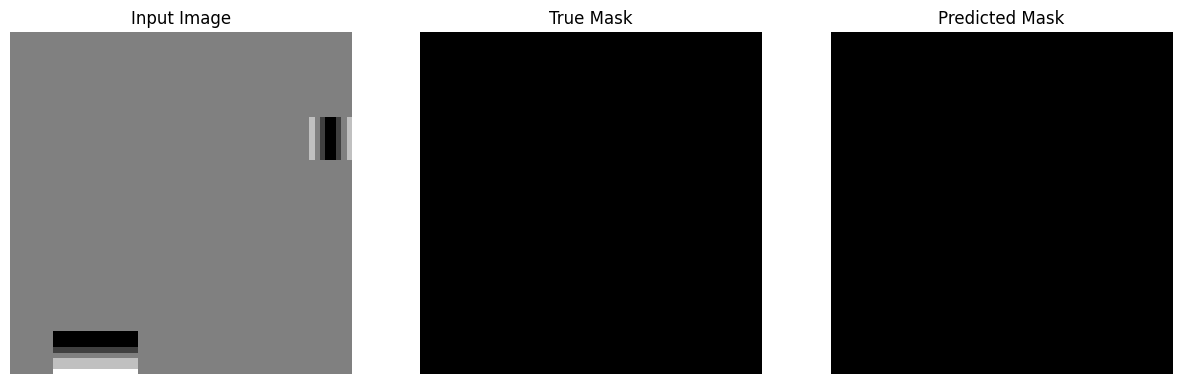

1/1 [==============================] - 0s 27ms/step


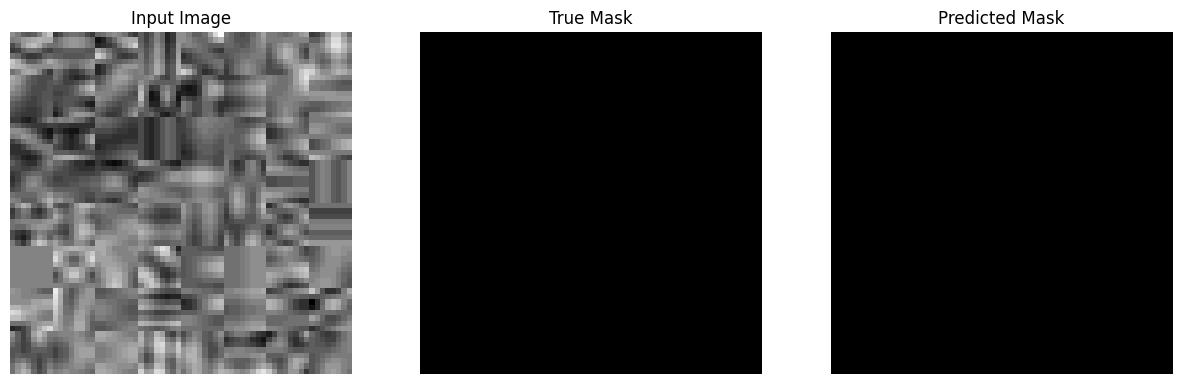

1/1 [==============================] - 0s 27ms/step


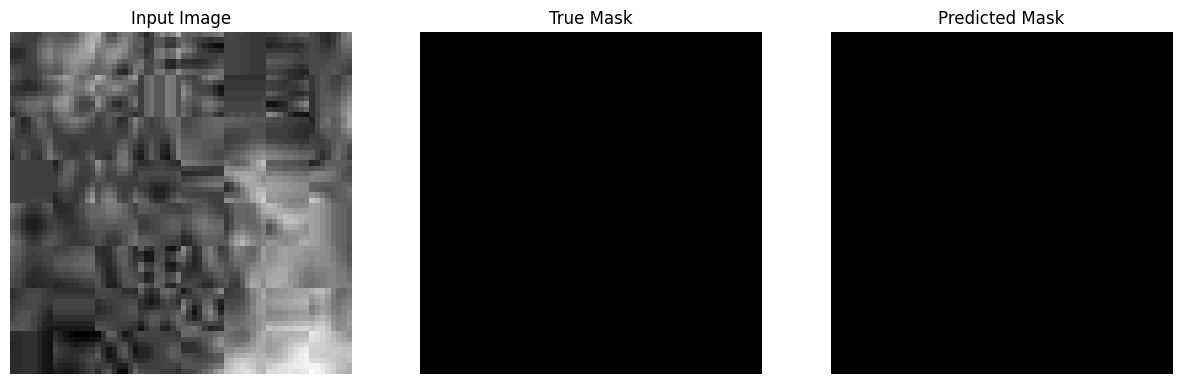

1/1 [==============================] - 0s 27ms/step


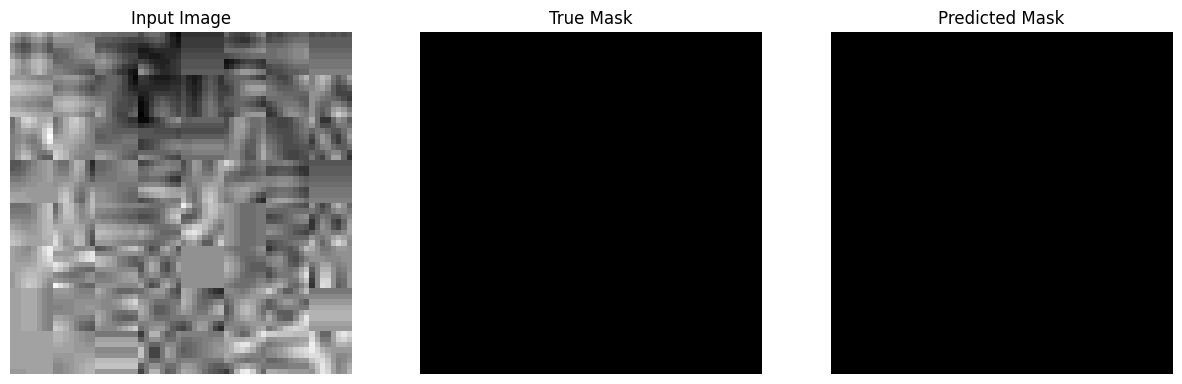

1/1 [==============================] - 0s 27ms/step


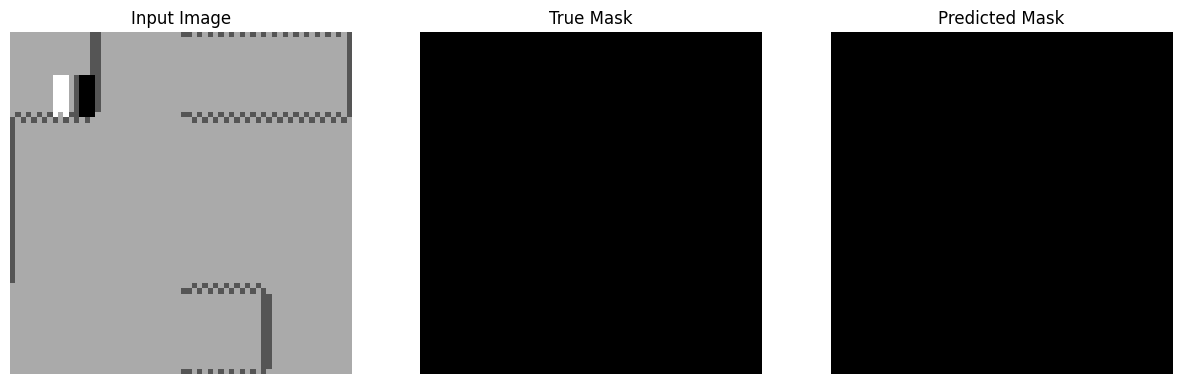

1/1 [==============================] - 0s 26ms/step


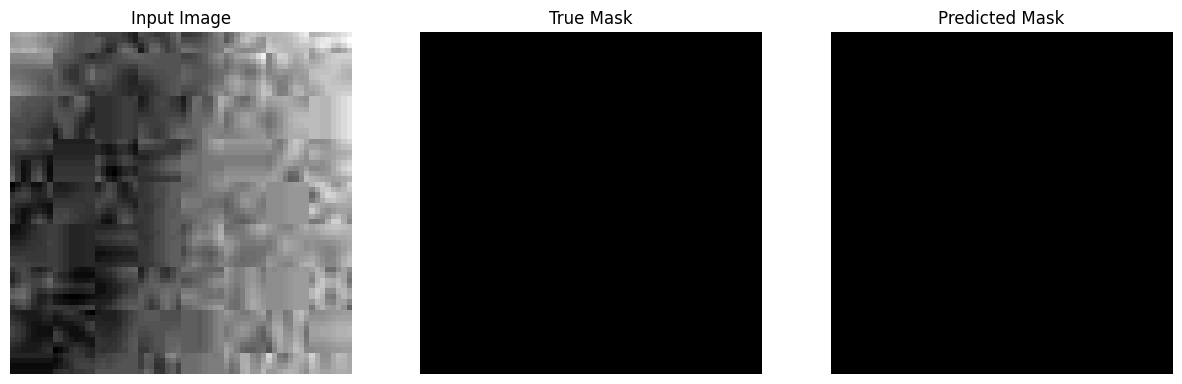

1/1 [==============================] - 0s 27ms/step


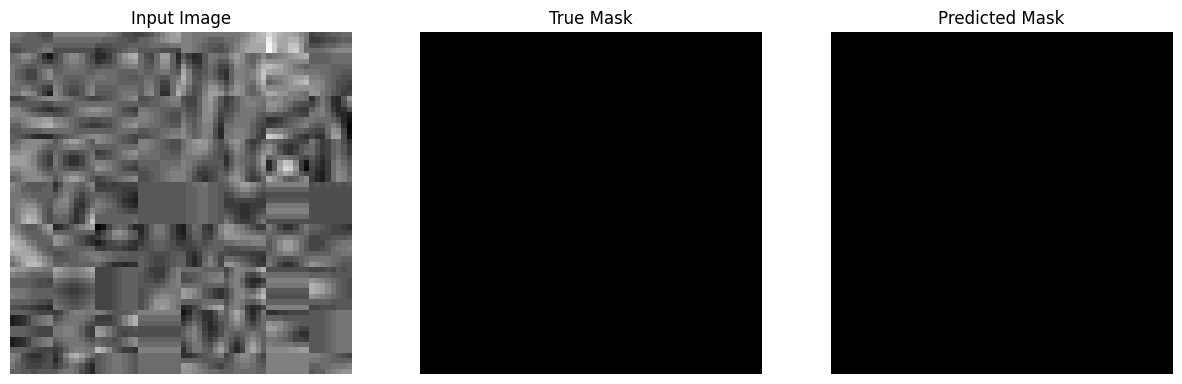

1/1 [==============================] - 0s 27ms/step


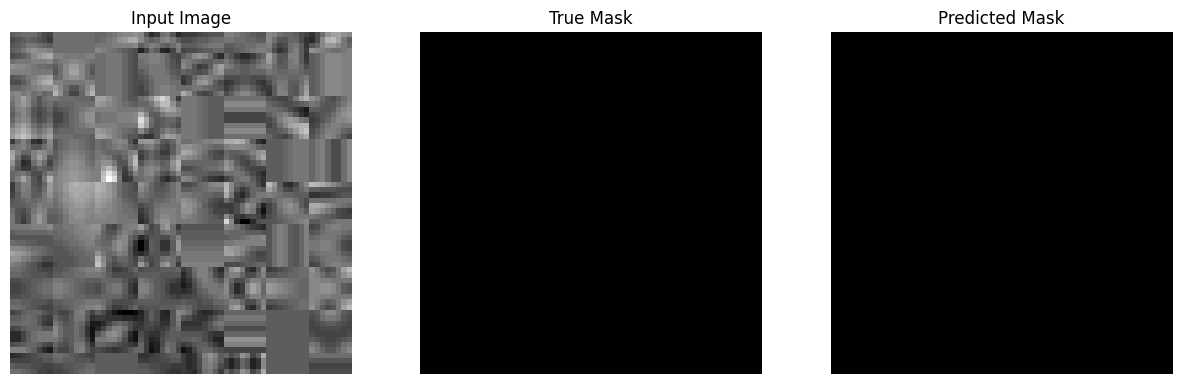

1/1 [==============================] - 0s 27ms/step


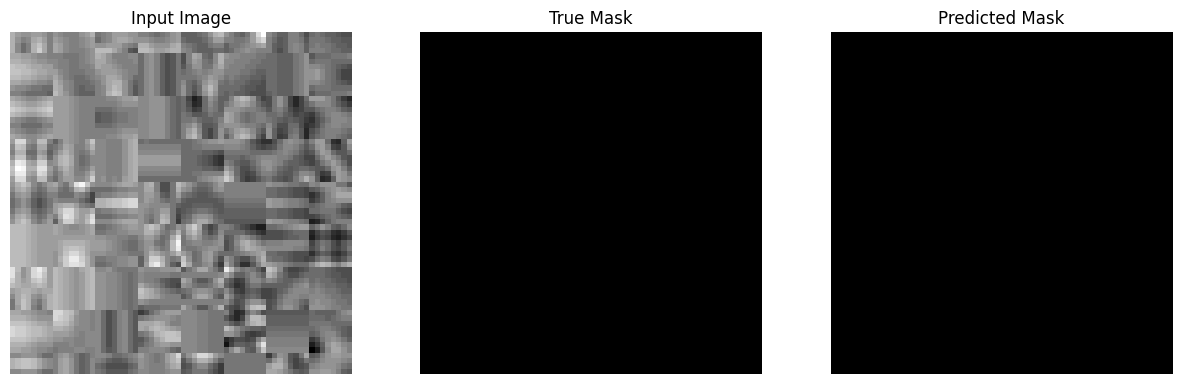

1/1 [==============================] - 0s 29ms/step


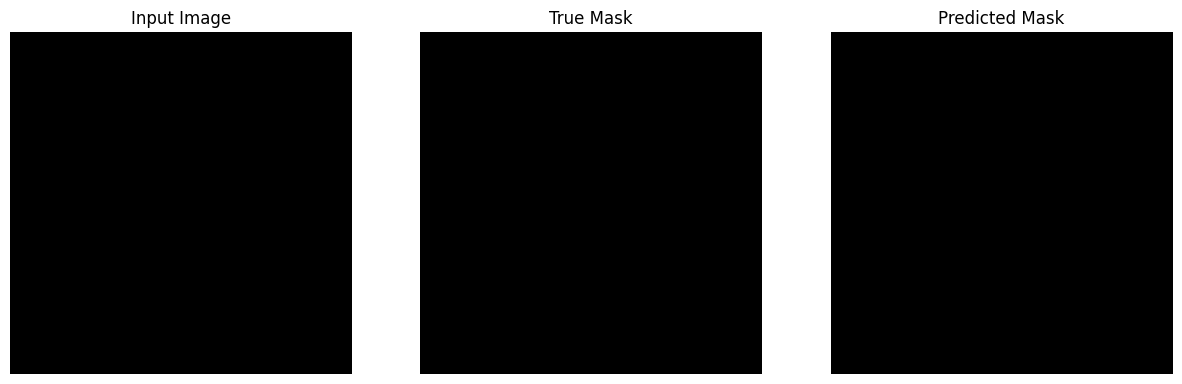

1/1 [==============================] - 0s 29ms/step


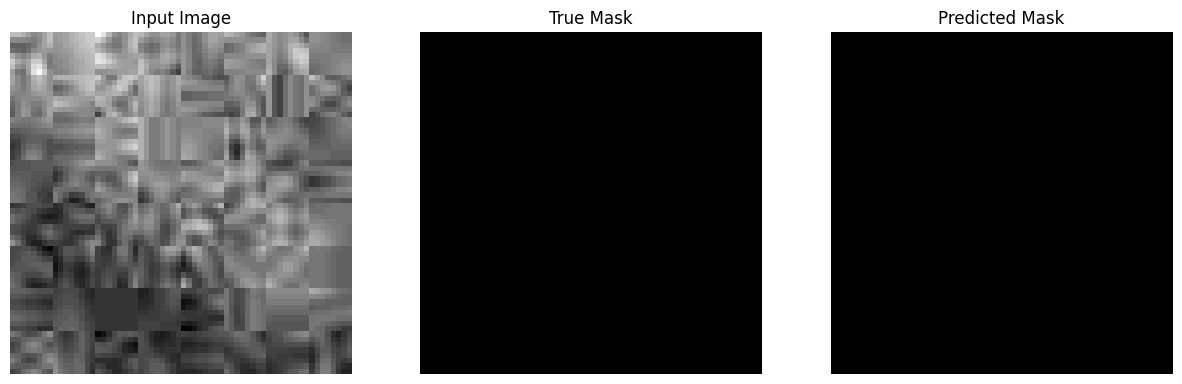

1/1 [==============================] - 0s 26ms/step


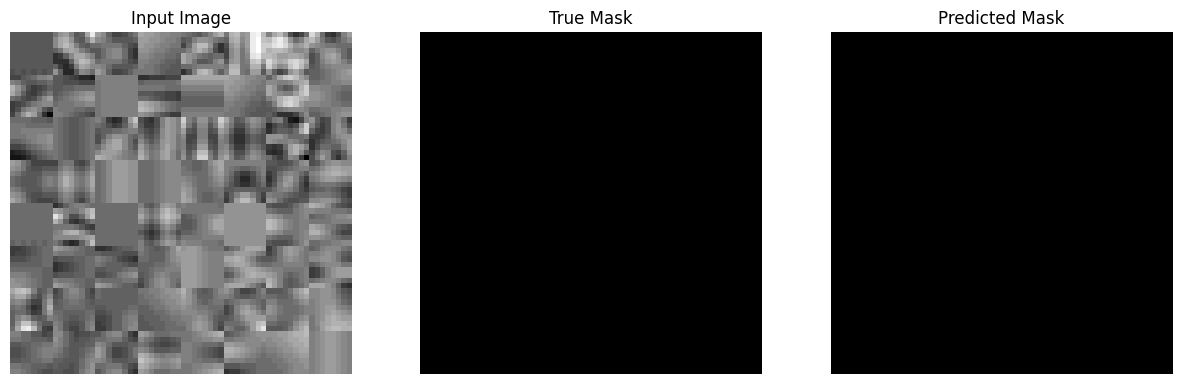

1/1 [==============================] - 0s 45ms/step


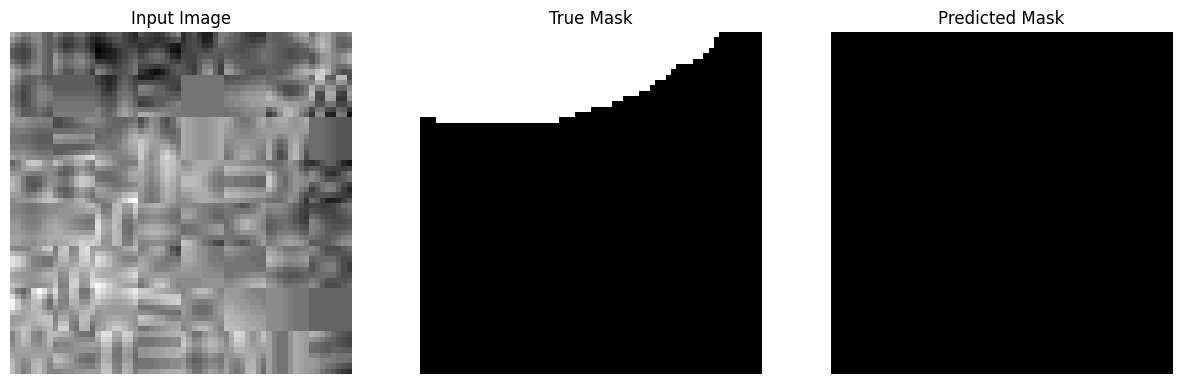

1/1 [==============================] - 0s 27ms/step


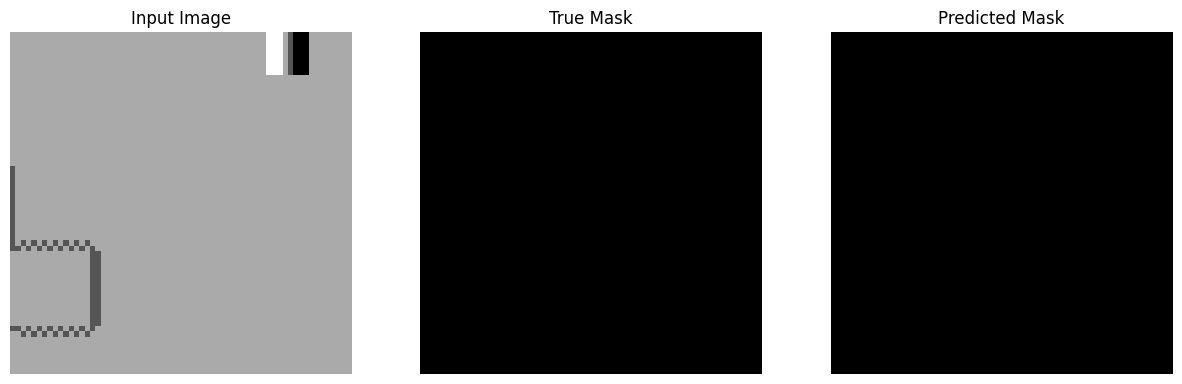

1/1 [==============================] - 0s 26ms/step


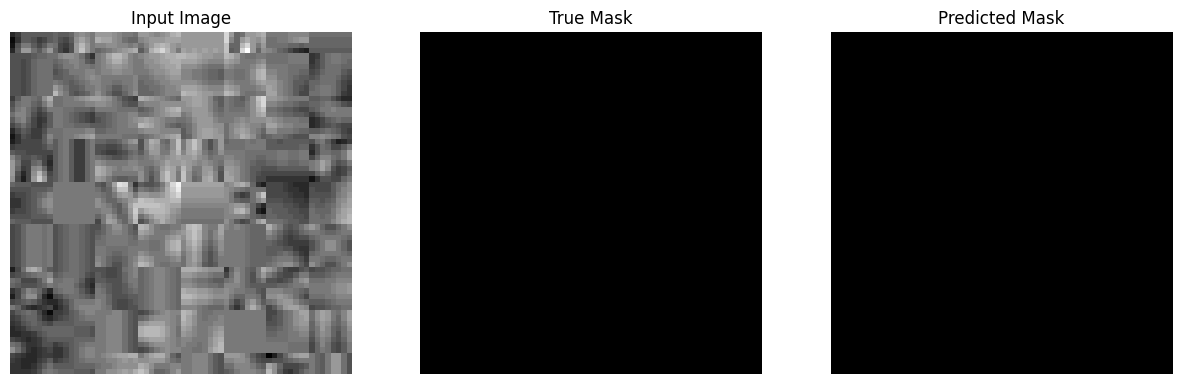

1/1 [==============================] - 0s 26ms/step


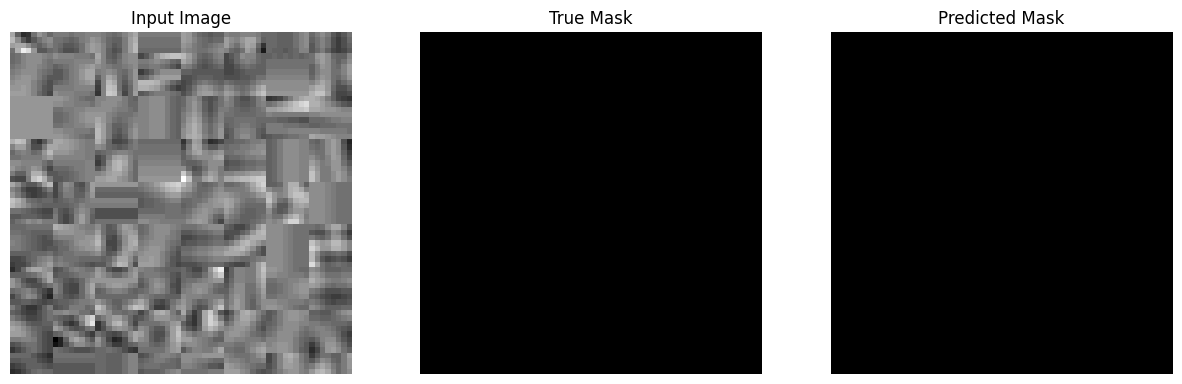

1/1 [==============================] - 0s 26ms/step


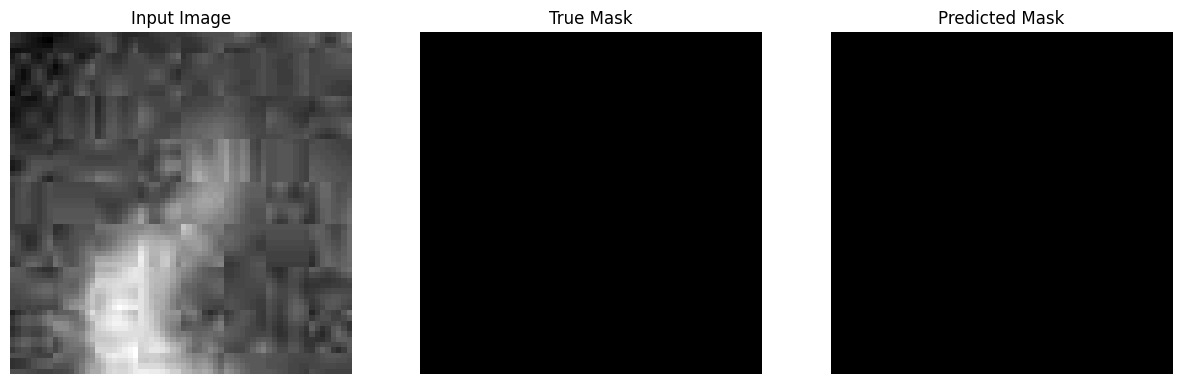

1/1 [==============================] - 0s 28ms/step


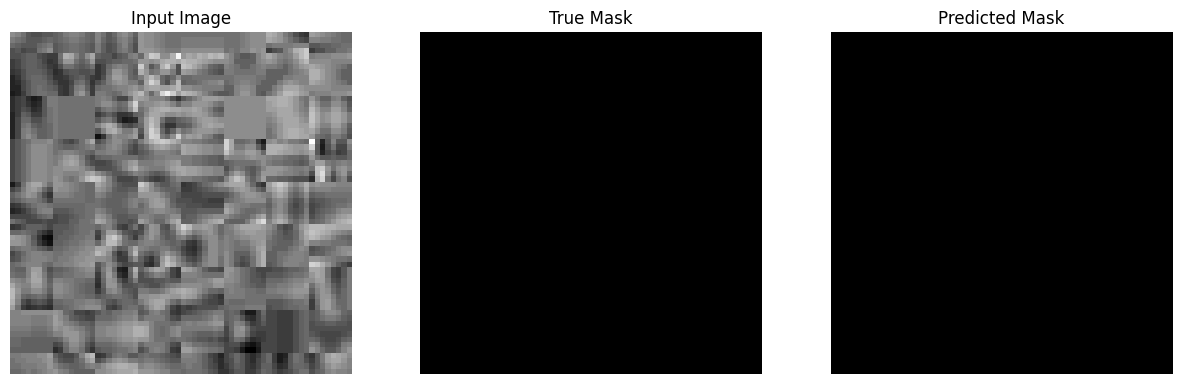

1/1 [==============================] - 0s 28ms/step


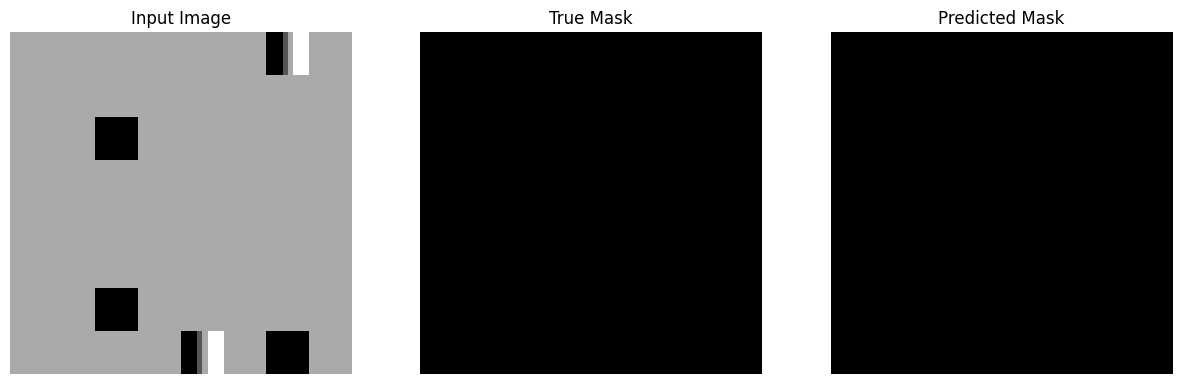

1/1 [==============================] - 0s 26ms/step


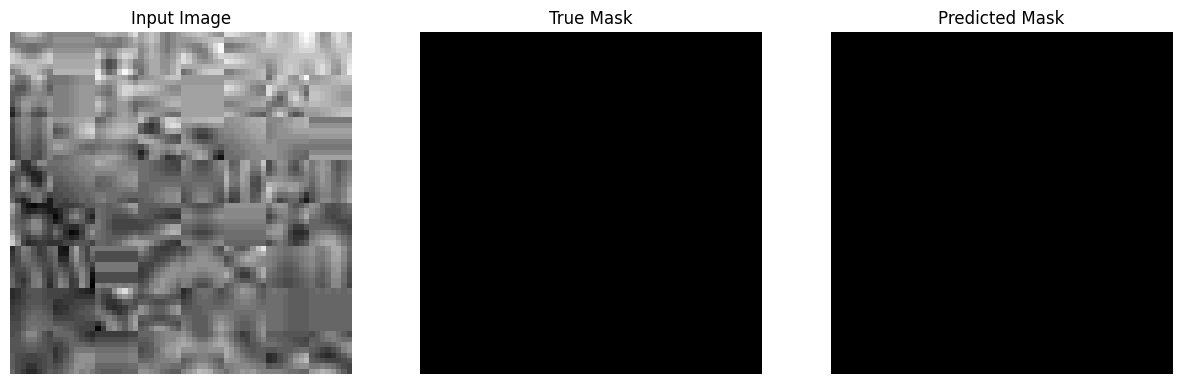

1/1 [==============================] - 0s 26ms/step


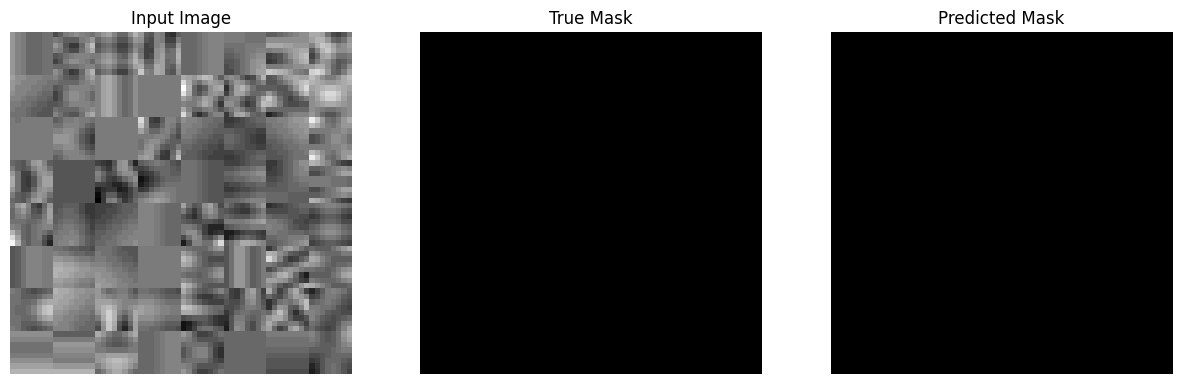

1/1 [==============================] - 0s 28ms/step


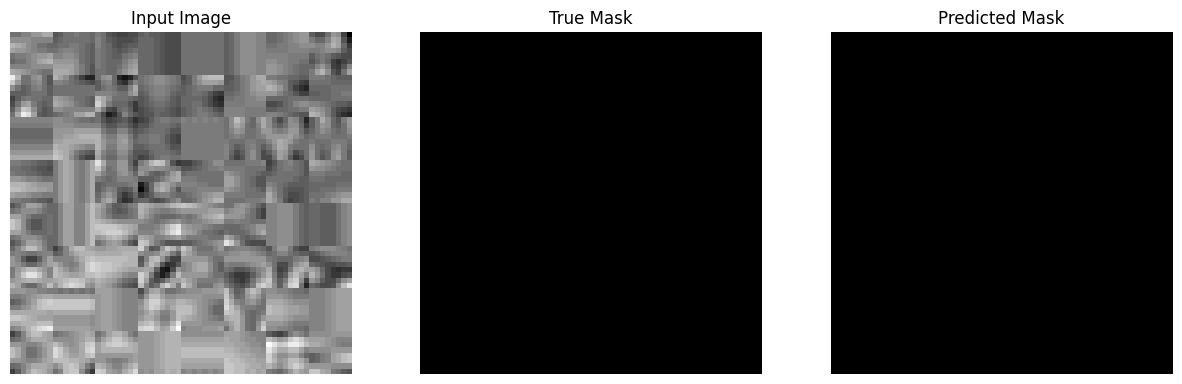

1/1 [==============================] - 0s 34ms/step


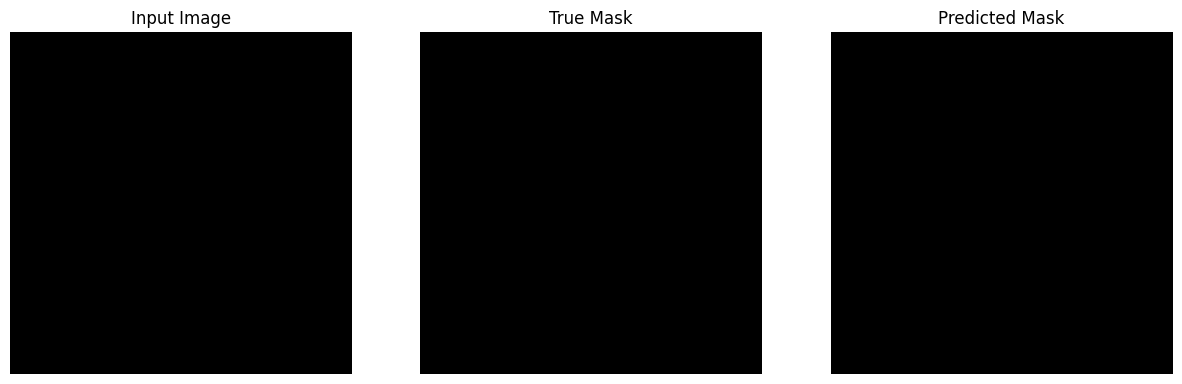

1/1 [==============================] - 0s 30ms/step


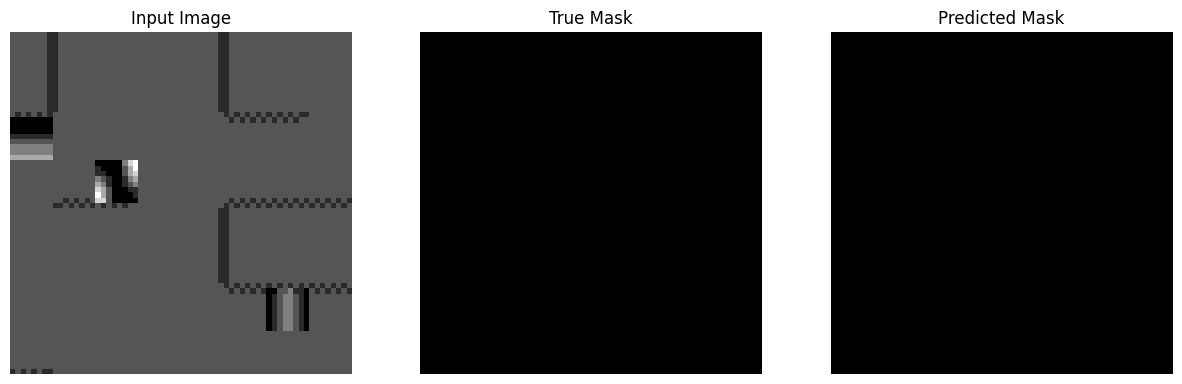

1/1 [==============================] - 0s 26ms/step


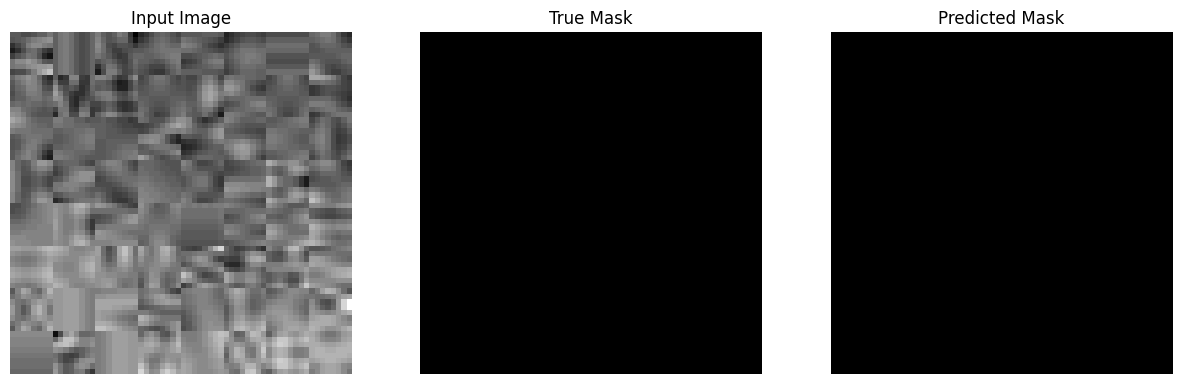

1/1 [==============================] - 0s 28ms/step


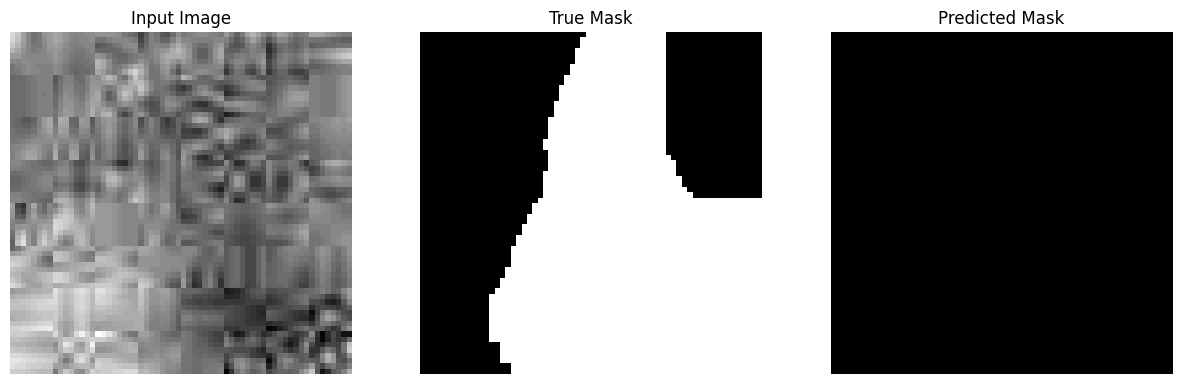

1/1 [==============================] - 0s 28ms/step


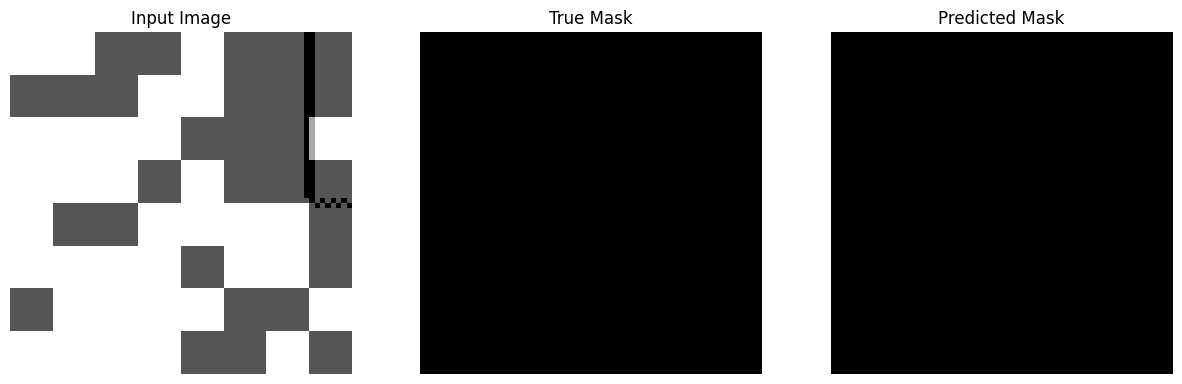

1/1 [==============================] - 0s 44ms/step


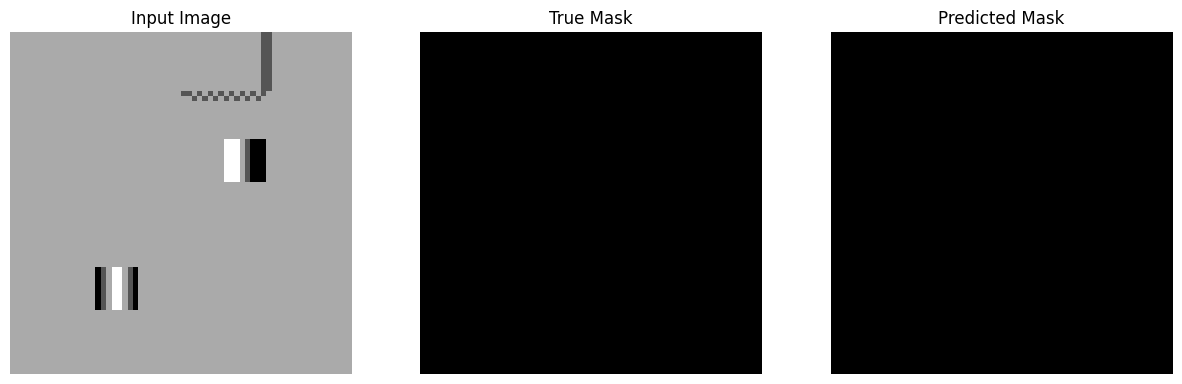

1/1 [==============================] - 0s 24ms/step


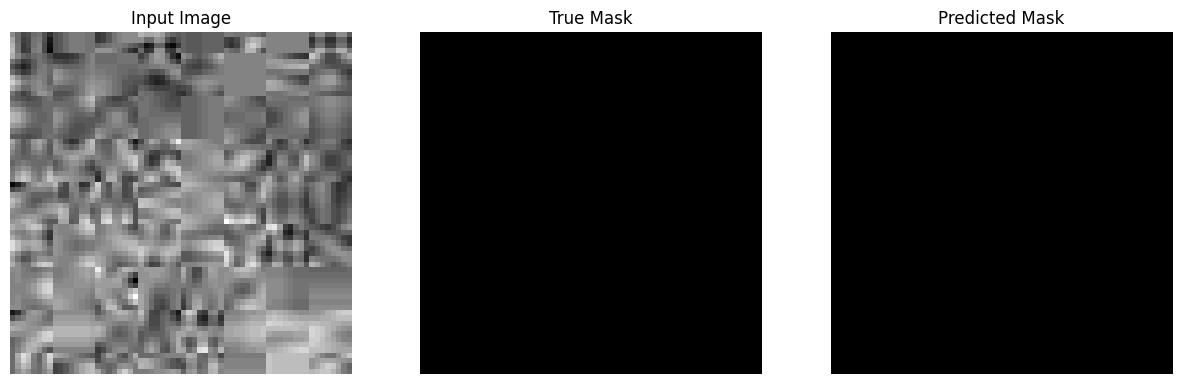

1/1 [==============================] - 0s 26ms/step


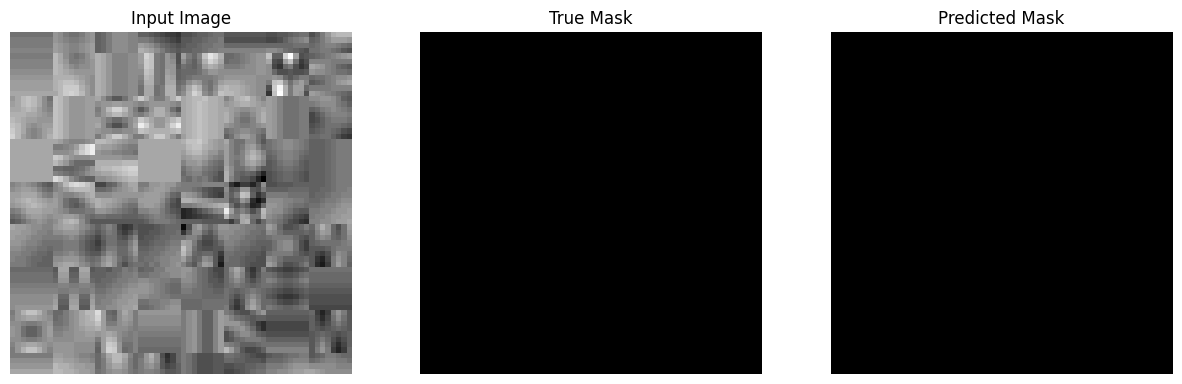

1/1 [==============================] - 0s 27ms/step


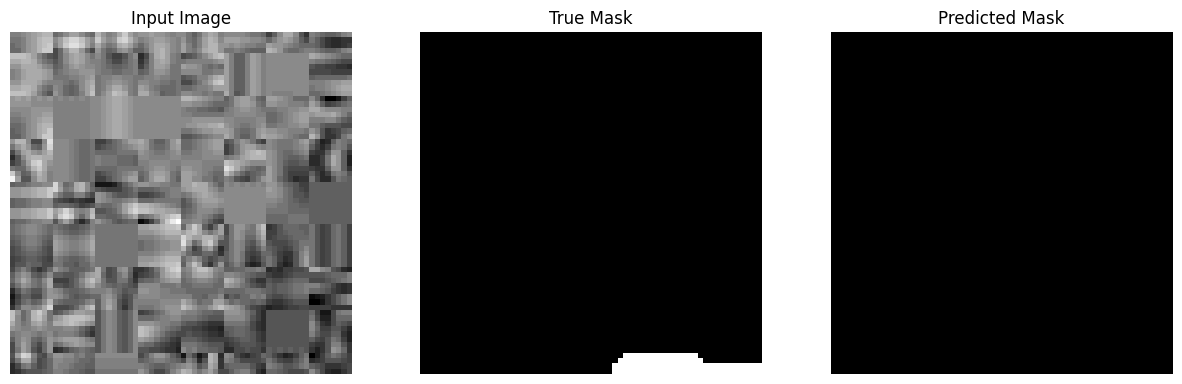

1/1 [==============================] - 0s 27ms/step


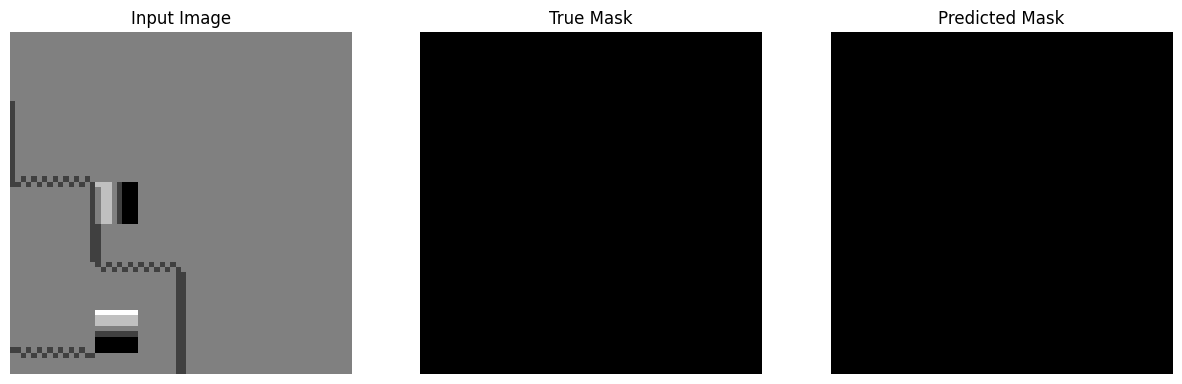

In [10]:
import matplotlib.pyplot as plt 

def displayPrediction(display_list, extra_title=''):
    plt.figure(figsize=(15, 15))
    title = ['Input Image', 'True Mask', 'Predicted Mask']

    if len(display_list) > len(title):
        title.append(extra_title)

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(display_list[i], cmap='gray')
        plt.axis('off')
    plt.show()
    
def create_mask(pred_mask):
    pred_mask = (pred_mask > 0.5).astype("int32")
    return pred_mask[0]
    
for image, mask in testDataset.take(50):
    pred_mask = model.predict(image)
    displayPrediction([image[0], mask[0], create_mask(pred_mask)])